In [20]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("data/delhi_metro_updated.csv")

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)
df.head(10)

Shape: (150000, 10)

Columns: ['TripID', 'Date', 'From_Station', 'To_Station', 'Distance_km', 'Fare', 'Cost_per_passenger', 'Passengers', 'Ticket_Type', 'Remarks']

Data types:
 TripID                  int64
Date                   object
From_Station           object
To_Station             object
Distance_km           float64
Fare                  float64
Cost_per_passenger    float64
Passengers            float64
Ticket_Type            object
Remarks                object
dtype: object


,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak
5,96371,2024-07-10,Kalkaji Mandir,Shivaji Park,3.91,29.20,30.64,22.0,Tourist Card,NaN
6,49743,2022-09-02,Mandi House,Jasola Vihar,1.49,175.32,33.45,14.0,Tourist Card,peak
7,47390,2023-12-07,Mandi House,Central Secretariat,7.38,167.59,50.69,18.0,Tourist Card,festival
8,58379,2024-05-05,AIIMS,Chandni Chowk,2.57,125.25,81.71,24.0,Single,weekend
9,69048,2022-07-05,New Delhi,Jasola Vihar,7.58,151.39,37.76,19.0,Tourist Card,peak


In [4]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDuplicate TripIDs:", df["TripID"].duplicated().sum())

df.describe()

Missing values per column:
 TripID                    0
Date                      0
From_Station              0
To_Station                0
Distance_km               0
Fare                      0
Cost_per_passenger        0
Passengers             1500
Ticket_Type            1500
Remarks               26257
dtype: int64

Duplicate rows: 0

Duplicate TripIDs: 0


,TripID,Distance_km,Fare,Cost_per_passenger,Passengers
count,150000.000000,150000.000000,150000.000000,150000.000000,148500.000000
mean,75000.500000,5.490446,105.116503,62.474807,20.003522
std,43301.414527,4.980333,54.879494,33.207161,4.468134
min,1.000000,0.500000,10.000000,5.000000,4.000000
25%,37500.750000,1.940000,57.570000,33.687500,17.000000
50%,75000.500000,3.960000,105.170000,62.520000,20.000000
75%,112500.250000,7.420000,152.572500,91.190000,23.000000
max,150000.000000,63.030000,200.000000,120.000000,41.000000


In [5]:
print("Ticket_Type values:\n", df["Ticket_Type"].value_counts(dropna=False))
print("\nRemarks values:\n", df["Remarks"].value_counts(dropna=False))
print("\nUnique From_Station count:", df["From_Station"].nunique())
print("Unique To_Station count:", df["To_Station"].nunique())

Ticket_Type values:
 Ticket_Type
Tourist Card    59193
Single          37341
Smart Card      37244
Return          14722
NaN              1500
Name: count, dtype: int64

Remarks values:
 Remarks
NaN            26257
off-peak       24859
festival       24812
maintenance    24771
weekend        24710
peak           24591
Name: count, dtype: int64

Unique From_Station count: 663
Unique To_Station count: 24


In [6]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Unparsed dates:", df["Date"].isnull().sum())

Date range: 2022-01-01 00:00:00 to 2024-12-30 00:00:00
Unparsed dates: 0


In [7]:
print("Sample of unique From_Station values:")
print(sorted(df["From_Station"].unique())[:40])

print("\nSample of unique To_Station values:")
print(sorted(df["To_Station"].unique()))

Sample of unique From_Station values:
['   AIIMS ', '   AIIMS  ', '   AIIMS   ', '   BARAKHAMBA ROAD ', '   BARAKHAMBA ROAD  ', '   BARAKHAMBA ROAD   ', '   Barakhamba Road ', '   Barakhamba Road  ', '   Barakhamba Road   ', '   CENTRAL SECRETARIAT ', '   CENTRAL SECRETARIAT  ', '   CENTRAL SECRETARIAT   ', '   CHANDNI CHOWK ', '   CHANDNI CHOWK  ', '   CHANDNI CHOWK   ', '   Central Secretariat ', '   Central Secretariat  ', '   Central Secretariat   ', '   Chandni Chowk ', '   Chandni Chowk  ', '   Chandni Chowk   ', '   DILSHAD GARDEN ', '   DILSHAD GARDEN  ', '   DILSHAD GARDEN   ', '   Dilshad Garden ', '   Dilshad Garden  ', '   Dilshad Garden   ', '   HAUZ KHAS ', '   HAUZ KHAS  ', '   HAUZ KHAS   ', '   Hauz Khas ', '   Hauz Khas  ', '   Hauz Khas   ', '   INDERLOK ', '   INDERLOK  ', '   INDERLOK   ', '   Inderlok ', '   Inderlok  ', '   Inderlok   ', '   JANAKPURI WEST ']

Sample of unique To_Station values:
['AIIMS', 'Barakhamba Road', 'Central Secretariat', 'Chandni Chowk',

In [8]:
missing_passengers = df[df["Passengers"].isnull()]
missing_ticket = df[df["Ticket_Type"].isnull()]

print("Rows missing Passengers:", len(missing_passengers))
print("Rows missing Ticket_Type:", len(missing_ticket))
print("Rows missing BOTH:", len(df[df["Passengers"].isnull() & df["Ticket_Type"].isnull()]))

Rows missing Passengers: 1500
Rows missing Ticket_Type: 1500
Rows missing BOTH: 14


In [9]:
# Strip whitespace and standardize casing
df_clean = df.copy()

df_clean["From_Station"] = df_clean["From_Station"].str.strip().str.title()
df_clean["To_Station"] = df_clean["To_Station"].str.strip().str.title()

print("From_Station unique count after cleaning:", df_clean["From_Station"].nunique())
print("To_Station unique count after cleaning:", df_clean["To_Station"].nunique())

print("\nFrom_Station values after cleaning:")
print(sorted(df_clean["From_Station"].unique()))

From_Station unique count after cleaning: 24
To_Station unique count after cleaning: 24

From_Station values after cleaning:
['Aiims', 'Barakhamba Road', 'Central Secretariat', 'Chandni Chowk', 'Dilshad Garden', 'Hauz Khas', 'Inderlok', 'Janakpuri West', 'Jasola Vihar', 'Kalkaji Mandir', 'Kashmere Gate', 'Kirti Nagar', 'Laxmi Nagar', 'Mandi House', 'Model Town', 'Netaji Subhash Place', 'New Delhi', 'Noida City Centre', 'Old Delhi', 'Pragati Maidan', 'Punjabi Bagh', 'Rajiv Chowk', 'Rajouri Garden', 'Shivaji Park']


In [10]:
same_station_trips = df_clean[df_clean["From_Station"] == df_clean["To_Station"]]
print("Trips where From_Station == To_Station:", len(same_station_trips))
same_station_trips.head()

Trips where From_Station == To_Station: 1323


,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
86,119867,2023-02-27,Rajiv Chowk,Rajiv Chowk,8.16,98.78,89.39,26.0,Tourist Card,off-peak
102,105029,2024-09-28,Mandi House,Mandi House,7.00,150.89,79.82,22.0,Tourist Card,NaN
113,17710,2022-04-21,Mandi House,Mandi House,9.16,175.99,48.65,8.0,Single,off-peak
152,18608,2022-07-07,Mandi House,Mandi House,1.72,109.35,104.19,22.0,Tourist Card,off-peak
191,65758,2024-12-18,Rajiv Chowk,Rajiv Chowk,4.79,130.59,8.56,18.0,Single,peak


In [11]:
print("Rows with Distance_km <= 0:", len(df_clean[df_clean["Distance_km"] <= 0]))
print("Rows with Fare <= 0:", len(df_clean[df_clean["Fare"] <= 0]))
print("Rows with Cost_per_passenger <= 0:", len(df_clean[df_clean["Cost_per_passenger"] <= 0]))
print("Rows with Passengers <= 0:", len(df_clean[df_clean["Passengers"] <= 0]))

Rows with Distance_km <= 0: 0
Rows with Fare <= 0: 0
Rows with Cost_per_passenger <= 0: 0
Rows with Passengers <= 0: 0


In [12]:
print("Before dropping:", df_clean.shape)
df_clean = df_clean[df_clean["From_Station"] != df_clean["To_Station"]]
print("After dropping same-station trips:", df_clean.shape)

Before dropping: (150000, 10)
After dropping same-station trips: (148677, 10)


In [13]:
# Ticket_Type: fill missing with "Unknown" rather than dropping (preserves the trip record)
df_clean["Ticket_Type"] = df_clean["Ticket_Type"].fillna("Unknown")

# Remarks: NaN likely means a "regular" trip with no special condition flagged
df_clean["Remarks"] = df_clean["Remarks"].fillna("Regular")

# Passengers: missing ~1% of rows — fill with the median (robust to outliers) rather than dropping data
median_passengers = df_clean["Passengers"].median()
df_clean["Passengers"] = df_clean["Passengers"].fillna(median_passengers)

print("Remaining missing values:\n", df_clean.isnull().sum())

Remaining missing values:
 TripID                0
Date                  0
From_Station          0
To_Station            0
Distance_km           0
Fare                  0
Cost_per_passenger    0
Passengers            0
Ticket_Type           0
Remarks               0
dtype: int64


In [14]:
print("Correlation between Distance_km and Fare:", df_clean["Distance_km"].corr(df_clean["Fare"]))
print("Correlation between Passengers and Fare:", df_clean["Passengers"].corr(df_clean["Fare"]))

Correlation between Distance_km and Fare: 0.0007970375650938906
Correlation between Passengers and Fare: -0.0004987115366904913


In [15]:
print("Average passengers by Remarks category:")
print(df_clean.groupby("Remarks")["Passengers"].mean().sort_values(ascending=False))

print("\nAverage passengers by Ticket_Type:")
print(df_clean.groupby("Ticket_Type")["Passengers"].mean().sort_values(ascending=False))

Average passengers by Remarks category:
Remarks
Regular        20.028242
maintenance    20.013242
off-peak       20.001136
weekend        20.000367
peak           19.990358
festival       19.978158
Name: Passengers, dtype: float64

Average passengers by Ticket_Type:
Ticket_Type
Smart Card      20.016843
Single          20.005462
Tourist Card    19.999010
Return          19.974682
Unknown         19.953660
Name: Passengers, dtype: float64


In [16]:
top_origins = df_clean["From_Station"].value_counts().head(10)
print("Top 10 busiest origin stations:\n", top_origins)

Top 10 busiest origin stations:
 From_Station
Rajiv Chowk            16994
Noida City Centre      13619
New Delhi               9867
Mandi House             9768
Dilshad Garden          6331
Kalkaji Mandir          6325
Central Secretariat     6318
Laxmi Nagar             6265
Chandni Chowk           6256
Model Town              6234
Name: count, dtype: int64


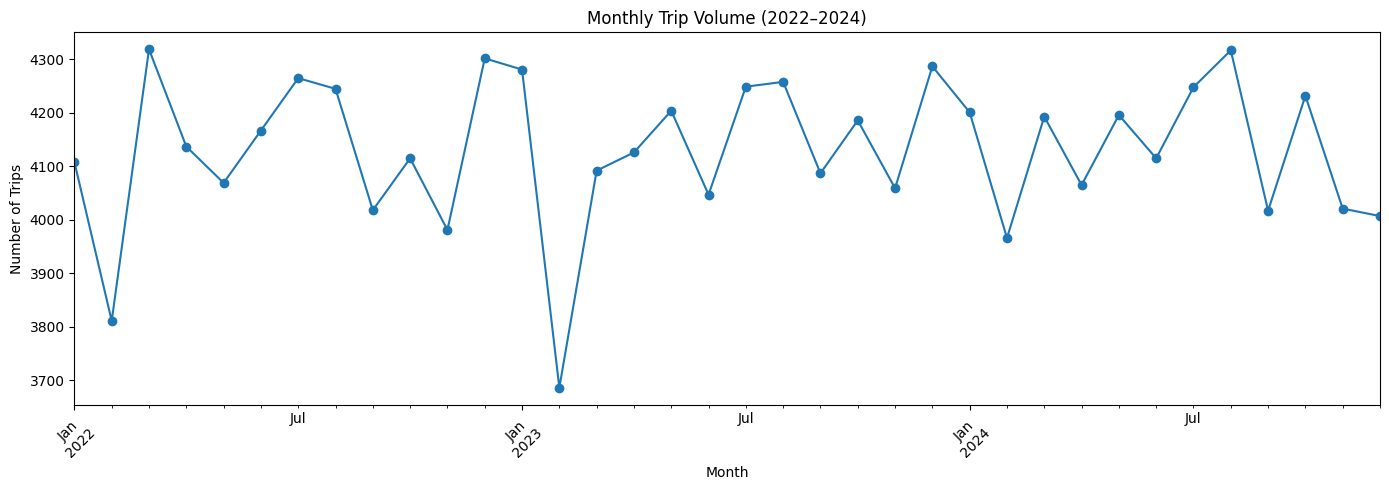

In [21]:
df_clean["Month"] = df_clean["Date"].dt.to_period("M")
monthly_trips = df_clean.groupby("Month").size()

plt.figure(figsize=(14, 5))
monthly_trips.plot(kind="line", marker="o")
plt.title("Monthly Trip Volume (2022\u20132024)")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
monthly_trips_df = monthly_trips.reset_index()
monthly_trips_df.columns = ["Month", "TripCount"]
print(monthly_trips_df.sort_values("TripCount").head(5))

      Month  TripCount
13  2023-02       3686
1   2022-02       3811
25  2024-02       3966
10  2022-11       3981
35  2024-12       4007


In [23]:
lowest_month = monthly_trips_df.sort_values("TripCount").iloc[0]["Month"]
dip_data = df_clean[df_clean["Month"] == lowest_month]
print(f"Trips in {lowest_month}:", len(dip_data))
print(dip_data["Remarks"].value_counts())

Trips in 2023-02: 3686
Remarks
Regular        663
off-peak       626
maintenance    625
festival       601
peak           595
weekend        576
Name: count, dtype: int64


In [24]:
monthly_trips_df["Days_in_Month"] = monthly_trips_df["Month"].dt.days_in_month
monthly_trips_df["Trips_per_Day"] = monthly_trips_df["TripCount"] / monthly_trips_df["Days_in_Month"]

print(monthly_trips_df.sort_values("Trips_per_Day").head(5))
print("\n")
print(monthly_trips_df["Trips_per_Day"].describe())

      Month  TripCount  Days_in_Month  Trips_per_Day
35  2024-12       4007             31     129.258065
4   2022-05       4069             31     131.258065
13  2023-02       3686             28     131.642857
14  2023-03       4092             31     132.000000
0   2022-01       4108             31     132.516129


count     36.000000
mean     135.646745
std        2.460552
min      129.258065
25%      134.008333
50%      135.860023
75%      137.399462
max      139.322581
Name: Trips_per_Day, dtype: float64


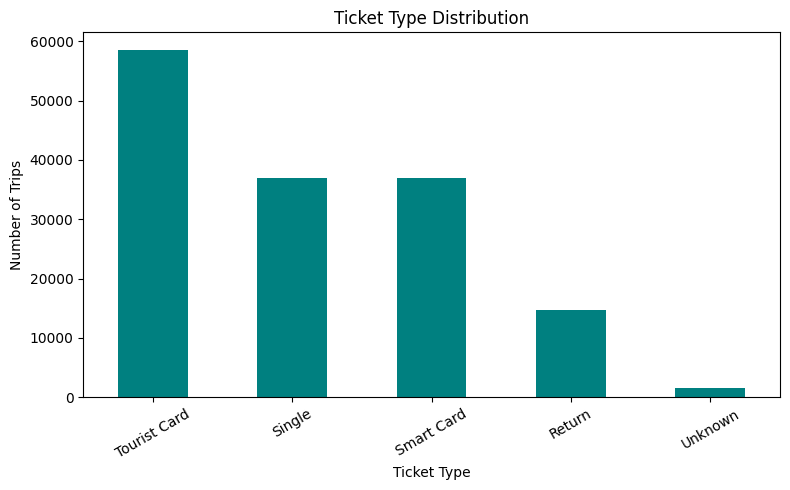

In [25]:
plt.figure(figsize=(8, 5))
df_clean["Ticket_Type"].value_counts().plot(kind="bar", color="teal")
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Trips")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

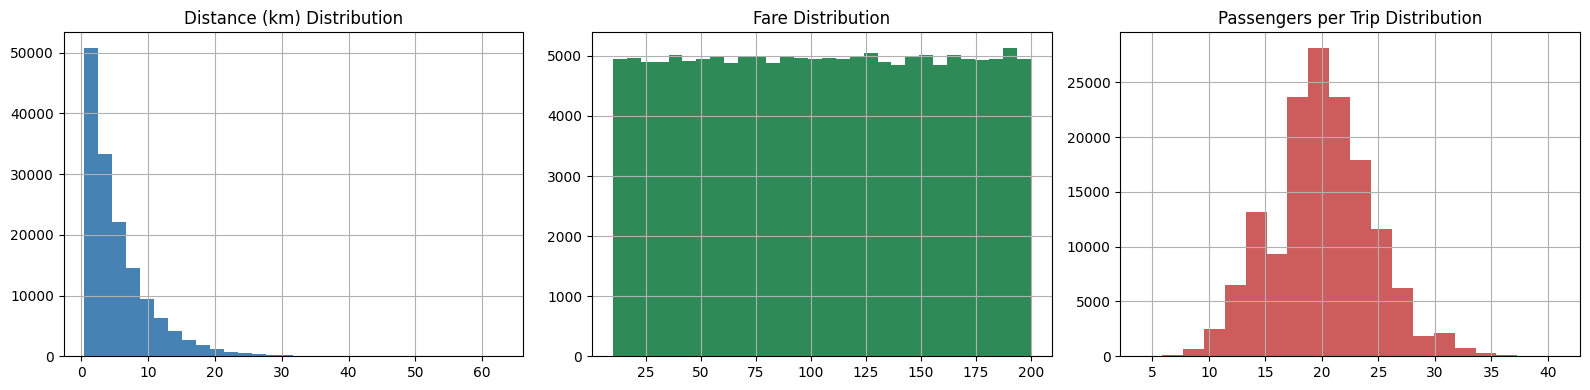

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_clean["Distance_km"].hist(bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distance (km) Distribution")

df_clean["Fare"].hist(bins=30, ax=axes[1], color="seagreen")
axes[1].set_title("Fare Distribution")

df_clean["Passengers"].hist(bins=20, ax=axes[2], color="indianred")
axes[2].set_title("Passengers per Trip Distribution")

plt.tight_layout()
plt.show()

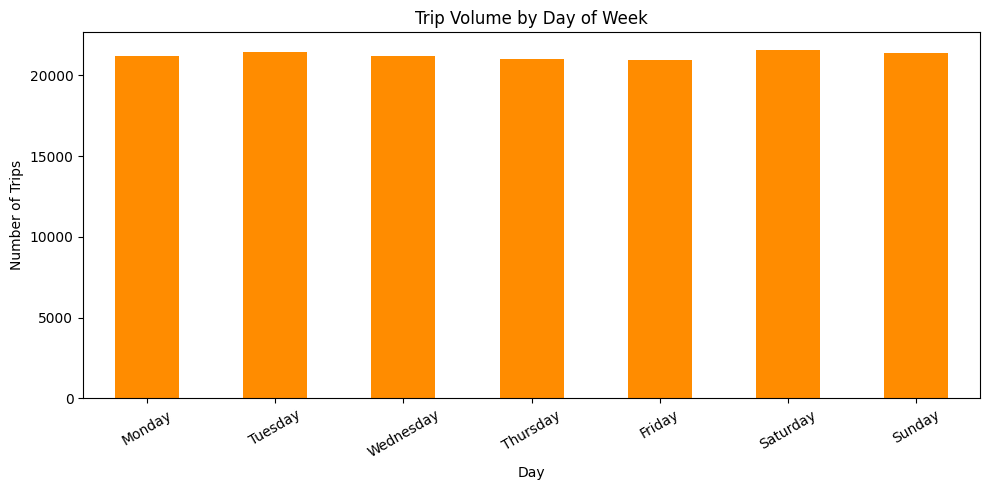

In [27]:
df_clean["Day_of_Week"] = df_clean["Date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 5))
df_clean["Day_of_Week"].value_counts().reindex(day_order).plot(kind="bar", color="darkorange")
plt.title("Trip Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

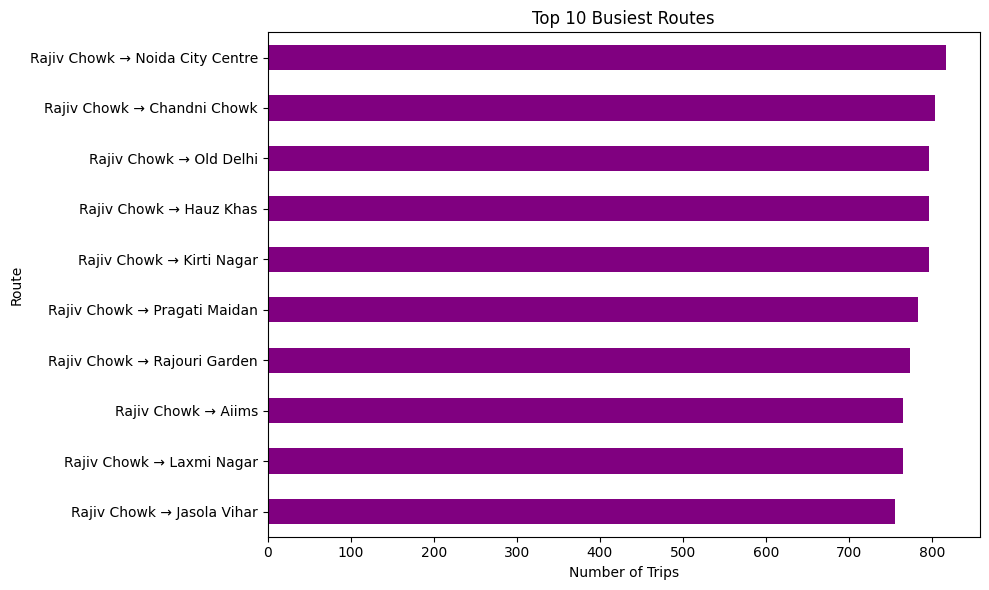

In [28]:
df_clean["Route"] = df_clean["From_Station"] + " \u2192 " + df_clean["To_Station"]
top_routes = df_clean["Route"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_routes.plot(kind="barh", color="purple")
plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Trips")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

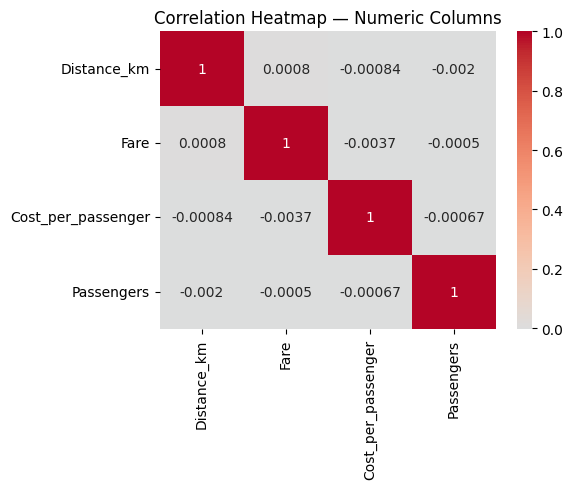

In [29]:
plt.figure(figsize=(6, 5))
sns.heatmap(df_clean[["Distance_km", "Fare", "Cost_per_passenger", "Passengers"]].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap \u2014 Numeric Columns")
plt.tight_layout()
plt.show()

In [30]:
df_final = df_clean.drop(columns=["Route"]) if "Route" in df_clean.columns else df_clean
df_final.to_csv("data/delhi_metro_ridership_cleaned.csv", index=False)
print("Saved cleaned ridership dataset:", df_final.shape)

Saved cleaned ridership dataset: (148677, 12)
